In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/raw/Xente_Variable_Definitions.csv")

df.head()

,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account


In [4]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [5]:
print("Shape:", df.shape)

df.info()

Shape: (95662, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  

In [6]:
df.nunique().sort_values(ascending=False)

TransactionId           95662
BatchId                 94809
TransactionStartTime    94556
CustomerId               3742
AccountId                3633
SubscriptionId           3627
Amount                   1676
Value                    1517
ProductId                  23
ProductCategory             9
ProviderId                  6
ChannelId                   4
PricingStrategy             4
FraudResult                 2
CurrencyCode                1
CountryCode                 1
dtype: int64

In [7]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [8]:
df.duplicated().sum()

0

In [14]:
df["TransactionId"].nunique()
 

95662

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


In [11]:
num_cols = [
    "Amount",
    "Value",
    "CountryCode",
    "PricingStrategy"
]

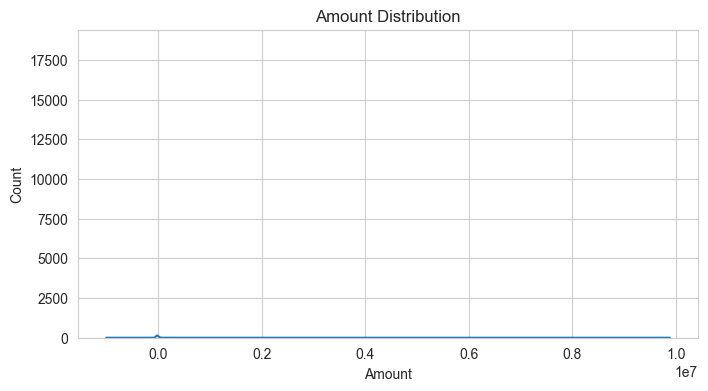

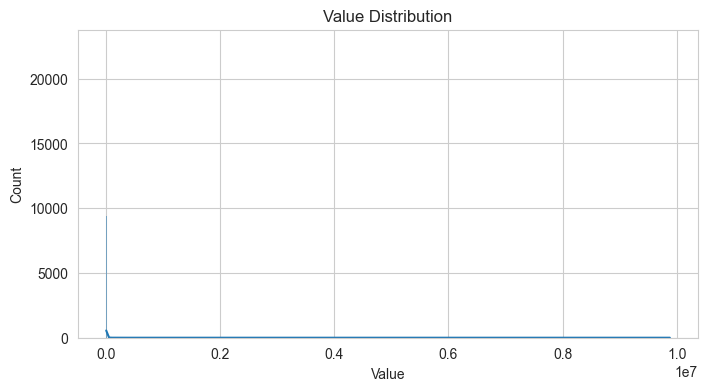

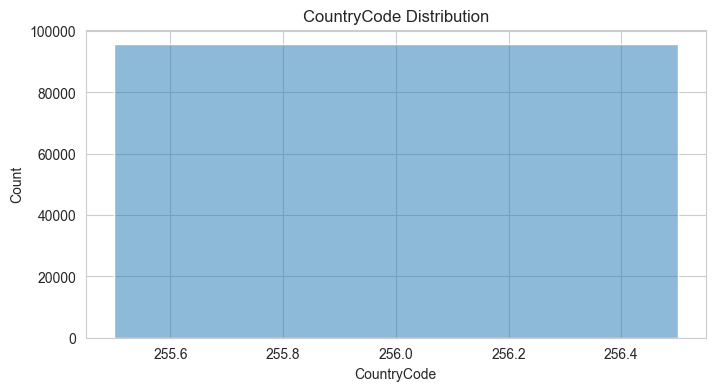

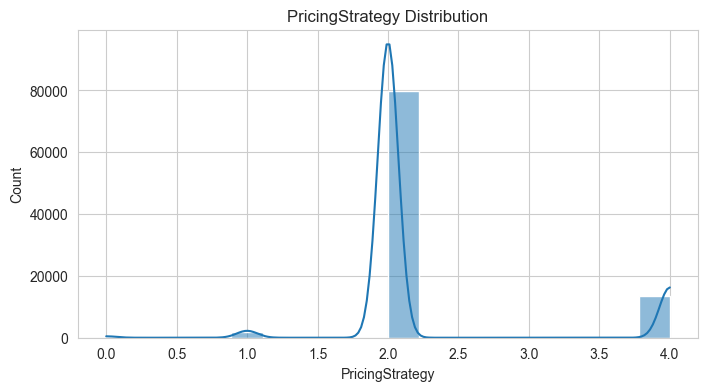

In [15]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

In [ ]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [ ]:
df["hour"] = df["TransactionStartTime"].dt.hour
df["day"] = df["TransactionStartTime"].dt.day
df["month"] = df["TransactionStartTime"].dt.month

<Axes: xlabel='hour', ylabel='count'>

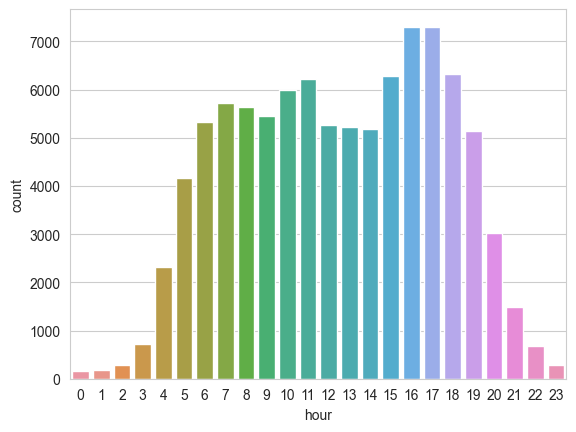

In [ ]:
sns.countplot(x="hour", data=df)

# Key Insights

1. The dataset contains 95,662 transaction records with no duplicate observations, indicating good overall data quality.

2. Transaction amounts are highly right-skewed, with a median value of 1,000 and a maximum value of 9,880,000, suggesting the presence of significant outliers and a small number of very large transactions.

3. Fraudulent transactions account for only approximately 0.2% of all transactions, creating a highly imbalanced classification problem that requires appropriate evaluation metrics beyond accuracy.

4. CountryCode contains only a single value (256) across all observations, indicating no geographical variation and limited predictive usefulness.

5. The dataset captures repeated customer interactions over time, making customer-level aggregation and behavioral feature engineering suitable approaches for constructing a credit-risk proxy variable.